In [12]:
import os
import obspy
import numpy as np
from tqdm import tqdm
from obspy.signal.trigger import recursive_sta_lta, trigger_onset

def batch_convert_earthquake_autocrop(root_dir, output_root):
    """
    Ekstraksi Data Gempa Cerdas (Hanya 1 Jendela per File .mseed)
    Menggunakan STA/LTA untuk mendeteksi datangnya gelombang secara otomatis.
    """
    
    # Hitung total file untuk progress bar
    total_files = sum([len(files) for r, d, files in os.walk(root_dir) if any(f.endswith('.mseed') for f in files)])
    pbar = tqdm(total=total_files, desc="Auto-Cropping Gempa (STA/LTA)")

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".mseed"):
                mseed_path = os.path.join(root, file)
                
                relative_path = os.path.relpath(root, root_dir)
                save_dir = os.path.join(output_root, relative_path)
                if not os.path.exists(save_dir):
                    os.makedirs(save_dir)
                
                try:
                    st = obspy.read(mseed_path)
                    tr = st.select(component='Z')[0] 
                    
                    # ==========================================
                    # 1. PRE-PROCESSING ZHI GENG
                    # ==========================================
                    tr.detrend('demean')
                    tr.detrend('linear')
                    
                    if tr.stats.sampling_rate != 100.0:
                        tr.resample(100.0)
                        
                    tr.filter('bandpass', freqmin=1.0, freqmax=20.0, corners=4, zerophase=True)
                    
                    # ==========================================
                    # 2. AUTO DETEKSI GEMPA (STA/LTA)
                    # ==========================================
                    data = tr.data
                    
                    # STA 0.5 detik, LTA 3 detik (Sangat sensitif terhadap P-Wave)
                    sta_len = int(0.5 * 100)
                    lta_len = int(3.0 * 100)
                    
                    if len(data) < lta_len:
                        pbar.update(1)
                        continue
                        
                    cft = recursive_sta_lta(data, sta_len, lta_len)
                    # Trigger ON jika rasio > 2.5 (lonjakan energi)
                    onsets = trigger_onset(cft, 2.5, 0.5)
                    
                    # ==========================================
                    # 3. POTONG & SIMPAN (HANYA 1 POTONGAN)
                    # ==========================================
                    if len(onsets) > 0:
                        p_arrival_idx = onsets[0][0]
                        
                        # Ambil 1 detik SEBELUM P-wave tiba, dan 6 detik SESUDAHNYA (Total 7 dtk)
                        start_idx = p_arrival_idx - 100 
                        if start_idx < 0:
                            start_idx = 0
                            
                        end_idx = start_idx + 700
                        
                        # Pastikan panjangnya cukup (tidak menabrak ujung akhir rekaman)
                        if end_idx <= len(data) and (end_idx - start_idx) == 700:
                            window = data[start_idx:end_idx]
                            
                            # Normalisasi Max-Absolute
                            max_val = np.max(np.abs(window))
                            if max_val > 0:
                                window = window / max_val
                                
                            window = window.astype(np.float32)
                                
                            file_name = f"{os.path.splitext(file)[0]}_AUTO.npy"
                            np.save(os.path.join(save_dir, file_name), window)
                            
                except Exception as e:
                    pass # Abaikan file yang korup
                
                pbar.update(1)
    
    pbar.close()

# ==========================================
# KONFIGURASI PATH
# ==========================================
# Ini path ke folder MSEED MENTAH Anda
ROOT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready"

# Ini path output untuk .NPY yang baru dan ilmiah
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_npy_zhi_geng_like"

print("🚀 Memulai ekstraksi cerdas (STA/LTA) data GEMPA dari mseed mentah...")
batch_convert_earthquake_autocrop(ROOT_DIR, OUTPUT_DIR)
print(f"✅ Selesai! Data gempa sekarang valid secara seismologi.")

🚀 Memulai ekstraksi cerdas (STA/LTA) data GEMPA dari mseed mentah...


Auto-Cropping Gempa (STA/LTA): 100%|██████████| 24183/24183 [03:00<00:00, 133.66it/s]

✅ Selesai! Data gempa sekarang valid secara seismologi.



=== INFO DATA GEMPA ===
Lokasi File : /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_npy_zhi_geng_like/2018/BMKG-20180616135250-001/YS_TL6B_BMKG-20180616135250-001_AUTO.npy
Dimensi   : (700,) (Ekspektasi: (700,))
Tipe Data : float32 (Ekspektasi: float32)
Nilai Max : 1.0000 (Ekspektasi: ~ 1.0)
Nilai Min : -0.8479 (Ekspektasi: ~ -1.0)
Rata-rata : 0.007792 (Ekspektasi: mendekati 0)


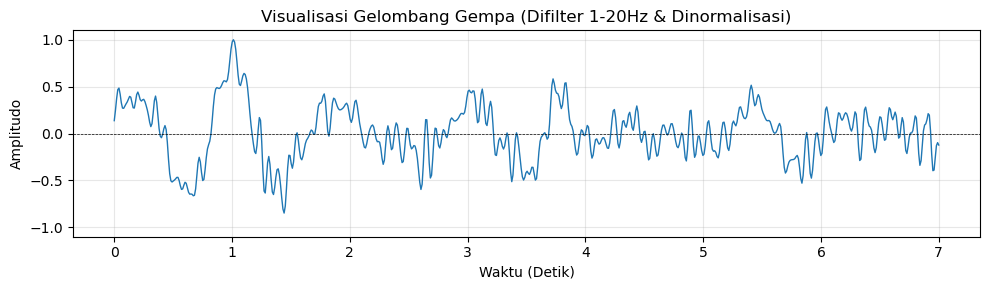


=== INFO DATA NOISE ===
Lokasi File : /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_npy_zhi_geng_like/2008/usp000gmyr/NOISE_GE_UGM_usp000gmyr.npy
Dimensi   : (700,) (Ekspektasi: (700,))
Tipe Data : float32 (Ekspektasi: float32)
Nilai Max : 0.1983 (Ekspektasi: ~ 1.0)
Nilai Min : -1.0000 (Ekspektasi: ~ -1.0)
Rata-rata : -0.019247 (Ekspektasi: mendekati 0)


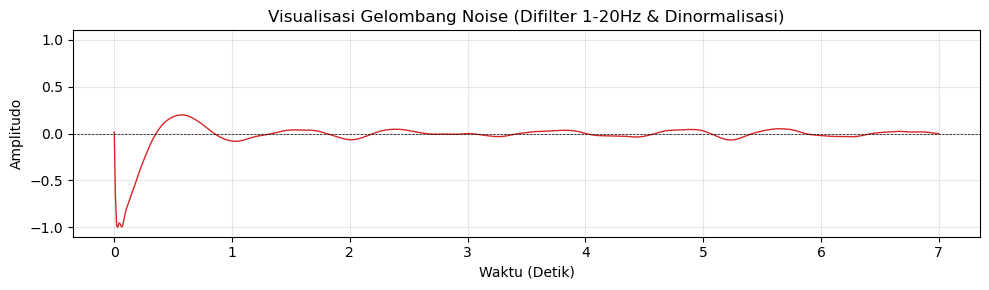

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

def inspect_and_plot_data(folder_path, label_name, color):
    # Cek apakah folder utama ada
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return
        
    # PERBAIKAN: Menggunakan os.walk untuk mencari file .npy hingga ke dalam sub-folder
    npy_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.npy'):
                npy_files.append(os.path.join(root, file))
                
    if not npy_files:
        print(f"❌ Tidak ada file .npy di folder {label_name} atau sub-foldernya.")
        return
    
    # Ambil 1 file acak dari seluruh file yang ditemukan
    file_path = random.choice(npy_files)
    sample_file = os.path.basename(file_path)
    
    # Load data
    data = np.load(file_path)
    
    # Print Info Statistik
    print(f"\n=== INFO DATA {label_name.upper()} ===")
    print(f"Lokasi File : {file_path}")
    print(f"Dimensi   : {data.shape} (Ekspektasi: (700,))")
    print(f"Tipe Data : {data.dtype} (Ekspektasi: float32)")
    print(f"Nilai Max : {np.max(data):.4f} (Ekspektasi: ~ 1.0)")
    print(f"Nilai Min : {np.min(data):.4f} (Ekspektasi: ~ -1.0)")
    print(f"Rata-rata : {np.mean(data):.6f} (Ekspektasi: mendekati 0)")
    
    # Plotting Gelombang
    plt.figure(figsize=(10, 3))
    # Buat sumbu X berbasis waktu (700 sampel / 100 Hz = 7 detik)
    time_axis = np.linspace(0, len(data)/100, len(data))
    
    plt.plot(time_axis, data, color=color, linewidth=1)
    plt.title(f"Visualisasi Gelombang {label_name} (Difilter 1-20Hz & Dinormalisasi)")
    plt.xlabel("Waktu (Detik)")
    plt.ylabel("Amplitudo")
    plt.ylim(-1.1, 1.1)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# KONFIGURASI PATH (Sudah dilengkapi)
# ==========================================
DIR_GEMPA = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_npy_zhi_geng_like"
DIR_NOISE = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_npy_zhi_geng_like"

# Cek Data Gempa (Warna Biru)
inspect_and_plot_data(DIR_GEMPA, label_name="Gempa", color="#1f77b4")

# Cek Data Noise (Warna Merah)
inspect_and_plot_data(DIR_NOISE, label_name="Noise", color="#d62728")

In [16]:
import os
import obspy
import numpy as np
from tqdm import tqdm

def extract_pre_event_noise(root_dir, output_root):
    """
    Mengekstrak 7 detik PERTAMA dari file mseed gempa sebagai data NOISE.
    Otomatis menelusuri seluruh sub-folder dan mempertahankan strukturnya.
    """
    # Hitung total file mseed untuk progress bar
    total_files = sum([len(files) for r, d, files in os.walk(root_dir) if any(f.endswith('.mseed') for f in files)])
    pbar = tqdm(total=total_files, desc="Ekstraksi Pre-Event Noise")

    # os.walk akan menyelam ke setiap sub-folder yang ada
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".mseed"):
                mseed_path = os.path.join(root, file)
                
                # Buat struktur sub-folder yang sama persis di folder tujuan
                relative_path = os.path.relpath(root, root_dir)
                save_dir = os.path.join(output_root, relative_path)
                os.makedirs(save_dir, exist_ok=True)
                
                try:
                    st = obspy.read(mseed_path)
                    tr = st.select(component='Z')[0] 
                    
                    # ==========================================
                    # 1. PRE-PROCESSING ZHI GENG
                    # ==========================================
                    tr.detrend('demean')
                    tr.detrend('linear')
                    
                    if tr.stats.sampling_rate != 100.0:
                        tr.resample(100.0)
                        
                    tr.filter('bandpass', freqmin=1.0, freqmax=20.0, corners=4, zerophase=True)
                    
                    # ==========================================
                    # 2. AMBIL 7 DETIK PERTAMA SEBAGAI NOISE
                    # ==========================================
                    data = tr.data
                    window_size = 700 # 7 detik @ 100 Hz
                    
                    # Pastikan panjang data cukup
                    if len(data) >= window_size:
                        # Potong HANYA index 0 sampai 700
                        window = data[:window_size]
                        
                        # Normalisasi Max-Absolute
                        max_val = np.max(np.abs(window))
                        if max_val > 0:
                            window = window / max_val
                            
                        # Format ke float32 (Standar Keras)
                        window = window.astype(np.float32)
                            
                        # Simpan dengan prefix NOISE_
                        file_name = f"NOISE_{os.path.splitext(file)[0]}.npy"
                        np.save(os.path.join(save_dir, file_name), window)
                        
                except Exception as e:
                    pass # Abaikan jika ada file mseed yang rusak
                
                pbar.update(1)
                
    pbar.close()

# ==========================================
# KONFIGURASI PATH
# ==========================================
# Path sumber (mengandung banyak sub-folder)
ROOT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready"

# Path tujuan untuk file Noise
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_npy_zhi_geng_like"

print("🚀 Mengekstrak masa tenang (Pre-Event Noise) dari seluruh sub-folder...")
extract_pre_event_noise(ROOT_DIR, OUTPUT_DIR)
print("✅ Selesai! Data NOISE berhasil disiapkan.")

🚀 Mengekstrak masa tenang (Pre-Event Noise) dari seluruh sub-folder...


Ekstraksi Pre-Event Noise: 100%|██████████| 24183/24183 [02:59<00:00, 134.49it/s]

✅ Selesai! Data NOISE berhasil disiapkan.


No training configuration found in save file, so the model was *not* compiled. Compile it manually.


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.


Memproses 24183 sampel untuk NOISE...


Memproses 24183 sampel untuk NOISE...
Memproses 24183 sampel untuk NOISE...
NOISE: 100%|██████████| 24183/24183 [01:20<00:00, 299.81it/s]


Memproses 23668 sampel untuk GEMPA...


Memproses 23668 sampel untuk GEMPA...
Memproses 23668 sampel untuk GEMPA...
GEMPA: 100%|██████████| 23668/23668 [01:18<00:00, 299.72it/s]

Accuracy: [0.7915596094552929, 0.7915596094552929]
Accuracy (avg.): 0.7915596094552929
True positive rate: [0.2877721574664614, 0.9994102168587242]
True positive rate (avg.): 0.7915596094552929
True negative rate: [0.9994102168587242, 0.2877721574664614]
True negative rate (avg.): 0.49562276486989276
Positive predictive value: [0.9950570342205323, 0.7727846769101242]
Positive predictive value (avg.): 0.8377045387222019
Negative predictive value: [0.7727846769101242, 0.9950570342205323]
Negative predictive value (avg.): 0.9301371724084546
False positive rate: [0.0005897831412757463, 0.7122278425335385]
False positive rate (avg.): 0.5043772351301072
False negative rate: [0.7122278425335385, 0.0005897831412757463]
False negative rate (avg.): 0.20844039054470706
False discovery rate: [0.00494296577946768, 0.22721532308987583]
False discovery rate (avg.): 0.1622954612777981
F1-score: [0.4464346639372228, 0.8716071852496636]
F1-score (avg.): 0.7474255656191607

--- HASIL EVALUASI FINAL ---
P


PPV: 0.7728, TPR: 0.9994, F1: 0.8716
PPV: 0.7728, TPR: 0.9994, F1: 0.8716


Hasil lengkap disimpan di: output 300815 benchmark metrics/MCU_5-20_INDONESIA_FOLDERS_BALANCED_30085154


Hasil lengkap disimpan di: output 300815 benchmark metrics/MCU_5-20_INDONESIA_FOLDERS_BALANCED_30085154
Hasil lengkap disimpan di: output 300815 benchmark metrics/MCU_5-20_INDONESIA_FOLDERS_BALANCED_30085154


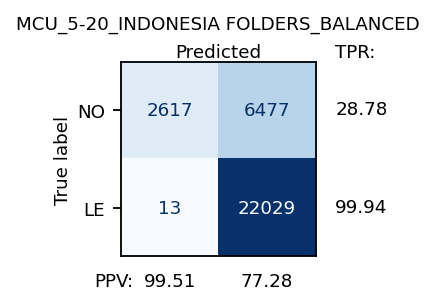

In [19]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
import logging
from datetime import datetime
import numpy as np
from tensorflow import keras
from tqdm import tqdm
import config 

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI KELAS & PATH
    #===================================================================
    true_labels = ["NO", "LE"]
    
    # Path ke folder .npy yang baru diekstrak
    DIR_NOISE = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_npy_zhi_geng_like"
    DIR_GEMPA = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_npy_zhi_geng_like"
    
    # Path Model (Format SavedModel / Folder langsung)
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    embedding_3C_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    MODEL_TAG = "MCU_5-20_INDONESIA"
    DATA_TAG = "FOLDERS_BALANCED"

    #===================================================================
    # 2. INISIALISASI LOGGER & LOAD MODEL
    #===================================================================
    save_dir = os.path.join(f"{config.OUTPUT_PATH} benchmark metrics", f"{MODEL_TAG}_{DATA_TAG}_{datetime.now().strftime('%d%H%M%S')}")
    os.makedirs(save_dir, exist_ok=True)
    logging.basicConfig(filename=os.path.join(save_dir, "task_log.txt"), level=logging.INFO, filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load menggunakan metode yang sudah terbukti berjalan di environment Anda
    embedding_model = keras.models.load_model(filepath=model_path)
    embedding_Z = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, Z.json")
    embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)

    #===================================================================
    # 3. INFERENSI REKURSIF DARI FOLDER
    #===================================================================
    total_true, total_pred = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)

    def process_directory(directory_path, true_label, desc):
        file_list = []
        for root, dirs, files in os.walk(directory_path):
            for f in files:
                if f.endswith('.npy'):
                    file_list.append(os.path.join(root, f))
                    
        logger.info(f"Memproses {len(file_list)} sampel untuk {desc}...")
        
        for file_path in tqdm(file_list, desc=desc):
            try:
                # Load dan bentuk matriks 2D (1, 700) untuk model
                data_z = np.load(file_path)[:num_points].reshape(1, -1)
                
                if data_z.shape[1] == num_points:
                    _input_Z = utils.latent_codes_1D(data_z, embedding_model)
                    _sources_code, _, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf="Kernel")
                    
                    if _sources_code < 2:
                        total_true.append(true_label)
                        total_pred.append(_sources_code)
            except Exception:
                pass

    # Eksekusi Inferensi (Noise = 0, Gempa = 1)
    process_directory(DIR_NOISE, 0, "NOISE")
    process_directory(DIR_GEMPA, 1, "GEMPA")

    #===================================================================
    # 4. EVALUASI DAN METRIK FINAL
    #===================================================================
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    if matrix.shape != (2, 2): matrix = matrix[:2, :2]
    
    tn, fp, fn, tp = matrix.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    print(f"\n--- HASIL EVALUASI FINAL ---")
    print(f"Precision (PPV): {ppv:.4f}")
    print(f"Recall (TPR)   : {tpr:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    
    logger.info(f"PPV: {ppv:.4f}, TPR: {tpr:.4f}, F1: {f1:.4f}")

    # Plot & Save
    fig = utils.plot_confusion(title=f"{MODEL_TAG} {DATA_TAG}",
                               true_labels=true_labels,
                               matrix=matrix,
                               metrics=metrics,
                               fig_size=[6, 5])
    
    fig.savefig(os.path.join(save_dir, "confusion_matrix.jpg"), dpi=300)
    dataset.save_json_data(os.path.join(save_dir, "metrics.json"), metrics)
    
    logger.info(f"Hasil lengkap disimpan di: {save_dir}")


=== MENGINTIP DATA GEMPA LAMA ===
File      : us20005he0_KAPI_seg.npy
Dimensi   : (700,)
Tipe Data : float32
Nilai Max : 1.0000
Nilai Min : -0.9270
Rata-rata : 0.016393


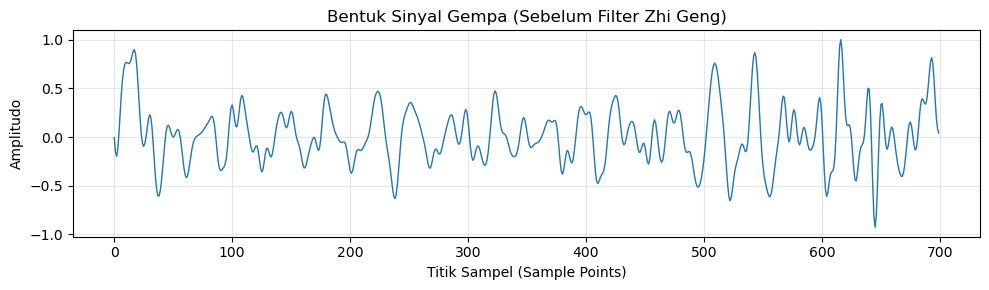


=== MENGINTIP DATA NOISE LAMA ===
File      : noise_UGM_1665222830.npy
Dimensi   : (700,)
Tipe Data : float32
Nilai Max : 1.0000
Nilai Min : -0.8105
Rata-rata : -0.005192


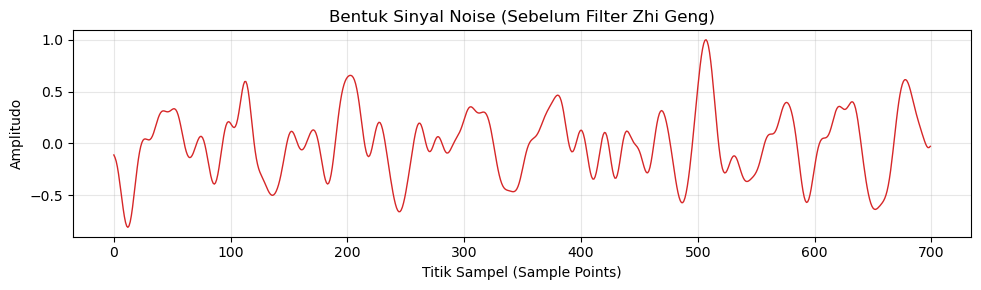

In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

def intip_data_npy(folder_path, label, color):
    # Kumpulkan semua file .npy
    npy_files = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.endswith('.npy'):
                npy_files.append(os.path.join(root, f))
                
    if not npy_files:
        print(f"❌ Tidak ada file .npy ditemukan di {folder_path}")
        return
        
    # Pilih 1 file secara acak
    file_pilihan = random.choice(npy_files)
    data = np.load(file_pilihan)
    
    print(f"\n=== MENGINTIP DATA {label.upper()} LAMA ===")
    print(f"File      : {os.path.basename(file_pilihan)}")
    print(f"Dimensi   : {data.shape}")
    print(f"Tipe Data : {data.dtype}")
    print(f"Nilai Max : {np.max(data):.4f}")
    print(f"Nilai Min : {np.min(data):.4f}")
    print(f"Rata-rata : {np.mean(data):.6f}")
    
    # Plot Grafik Sinyal
    plt.figure(figsize=(10, 3))
    plt.plot(data, color=color, linewidth=1)
    plt.title(f"Bentuk Sinyal {label} (Sebelum Filter Zhi Geng)")
    plt.xlabel("Titik Sampel (Sample Points)")
    plt.ylabel("Amplitudo")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# KONFIGURASI PATH FOLDER LAMA
# ==========================================
DIR_OLD_GEMPA = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready"
DIR_OLD_NOISE = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready"

# Intip Gempa (Biru)
intip_data_npy(DIR_OLD_GEMPA, "Gempa", "#1f77b4")

# Intip Noise (Merah)
intip_data_npy(DIR_OLD_NOISE, "Noise", "#d62728")